### 0. Wstęp

Ta część kodu dotyczy modeli które uczą się i są testowane na plikach .npy z folderu Spectrograms. 
Folder ten zawiera tablice numpy o wymiarach 128 x 128, które są MEL-spektrogramami z 3 sekondowych wycinków utworów

Porównane zostaną 
- MLP na spłaszczonym spektrogramie (długość az 128 x 128)
- Standardowa sieć CNN o wejściu 128 x 128 z klasyfikatorem MLP na końcu
- Głęboka sieć z połączeniami rezydualnymi, podobna do znanej sieci ResNet18, ale dostosowana do uzywanych tu wymiarów

Plik wykorzystuje $good\_labels.csv$, które odpowiadają plikom z $labels.csv$, które udało się przetransformować na niepusty spektrogram.
Do track_id z $labels.csv$ dodano końcówki $\_s1$, $\_s2$, $\_s3$, poniewaz kazdy utwór otrzymał 3 utwory-dzieci 

### Czym jest spektrogram i jak rózne parametry wpływają na zachowanie spektrogramu?
$Spektrogram$ to reprezentacja dźwięku w domenie czas–częstotliwość. Zamiast patrzeć na sygnał audio jako na jednowymiarową falę 
x[n], dzielimy go na krótkie fragmenty (okna czasowe) i dla każdego fragmentu liczymy, jakie częstotliwości są w nim obecne. 
Technicznie robimy to przez krótkookresową transformatę Fouriera


OŚ X:
- $seconds$ - ile sekund dzwięku wsadzamy do spektrogramu (nie jest to równoznaczne z osią X, zalezy ona od dalszych paramertów)
- $sr$ - z jaką częstotliwością nagrywany był dźwięk (odpowiednik frames per second dla filmu) 
$sr / 2$ to maksymalna częstotliwość którą komputer moze wyreprezentować
całe nagranie dla komputera ma zatem $seconds * sr$ "kratek"
- $hop\_length$ o ile kratek przesuwamy okno transormaty fouriera w czasie jednej sekundy.
Im mniejszy hop-length tym gęstsza oś X


OŚ Y:

- $n\_mels$ - na ile kubełków dzielimy zakres częstotliwości (do niej wpadają poszczególne sygnały w wykorzystywanej transformacie fouriera)
- $f\_min$, $f\_max$ - zakres interesującej nas częstotliwości



Uzywane spektrogramy wytworzone były wg ponizszego przepisu z wykorzystaniem funkcji $librosa.feature.melspectrogram$
```python
    seconds: float = 3.0,
    sr: int = 22050,
    n_mels: int = 128,
    n_fft: int = 2048,
    hop_length: int = 512,
    fmin: float = 20.0,
    fmax: float | None = 8000.0,
    top_db: float = 80.0,
    time_bins: int = 128,
    seed: int | None = None,


wymagania systemowe:

pytorch,
torchview, (wizualizacja sieci)

## 0. Przygotowanie danych i przydatnych funkcji

### 0.1 konfig oraz przygotowanie danych

In [31]:
#naprawa wyskakującego błędu
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

#importy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import random

#konfiguracja modelu i ustawienie danych wejściowych
class Config:
    CSV_PATH = 'good_labels.csv'
    SPECTROGRAMS_DIR = 'spectrograms'
    
    IMG_HEIGHT = 128
    IMG_WIDTH = 128
    INPUT_SIZE = IMG_HEIGHT * IMG_WIDTH 
    
    SEED = 123
    BATCH_SIZE = 64         
    LEARNING_RATE = 0.0002    
    EPOCHS = 30               
    
    random.seed(SEED)
    np.random.seed(SEED)

    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

#sprawdzenie poprawności i przygotowanie danych
def prepare_data():
    print("[KROK 1] Weryfikacja danych...")

    # czy jest tu wgl plik
    
    if not os.path.exists(Config.SPECTROGRAMS_DIR):
        raise FileNotFoundError(f"BŁĄD: Nie znaleziono folderu '{Config.SPECTROGRAMS_DIR}'!")
    if not os.path.exists(Config.CSV_PATH):
        raise FileNotFoundError(f"BŁĄD: Nie znaleziono pliku '{Config.CSV_PATH}'!")



    df = pd.read_csv(Config.CSV_PATH, dtype={'track_id': str})
    
    def check_file_exists(track_id):
        path = os.path.join(Config.SPECTROGRAMS_DIR, f"{track_id}.npy")
        return os.path.exists(path)

    print("   -> Sprawdzam spójność plików...")
    df['file_exists'] = df['track_id'].apply(check_file_exists)
    df_clean = df[df['file_exists'] == True].copy()
    
    print(f"   -> Znaleziono: {len(df_clean)} plików .npy.")
    if len(df_clean) == 0:
        raise RuntimeError("BŁĄD KRYTYCZNY: Folder pusty lub złe nazwy plików!")

    le = LabelEncoder()
    labels_encoded = le.fit_transform(df_clean['track_genre'])
    
    X_ids = df_clean['track_id'].values
    y_labels = labels_encoded
    
    ########## dzielimy tracki na treningowy i testowy po parent_id - inaczej mielibyśmy information leak między testowym a treningowym
        
    parent_ids = np.array([tid[:6] for tid in X_ids], dtype=str)   # or tid.split("_")[0]


    unique_parents, first_idx = np.unique(parent_ids, return_index=True)
    y_parent = y_labels[first_idx]

 
    parent_train, parent_test, y_parent_train, y_parent_test = train_test_split(
        unique_parents,
        y_parent,
        test_size=0.2,
        random_state=Config.SEED,
        stratify=y_parent,
    )


    train_mask = np.isin(parent_ids, parent_train)
    test_mask  = np.isin(parent_ids, parent_test)

    X_train_ids = X_ids[train_mask]
    y_train     = y_labels[train_mask]

    X_test_ids  = X_ids[test_mask]
    y_test      = y_labels[test_mask]
    ##########
    
    num_classes = len(le.classes_)
    return X_train_ids, X_test_ids, y_train, y_test, le, num_classes




### 0.2 Obiekty $Dataset$ dla modeli typu CNN oraz MLP

In [32]:
#wgranie datasetu

class SpectrogramDataset(Dataset):
    def __init__(self, track_ids, labels, root_dir):
        self.track_ids = track_ids
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.root_dir = root_dir
        
    def __len__(self):
        return len(self.track_ids)
    
    def __getitem__(self, idx):
        track_id = self.track_ids[idx]
        file_path = os.path.join(self.root_dir, f"{track_id}.npy")
        
        spectrogram = np.load(file_path).astype(np.float32)


            
        return torch.from_numpy(spectrogram), self.labels[idx]
    

class SpectrogramCnnDataset(SpectrogramDataset):
    """
    Dziedziczy z klasy SpectrogramDataset:
    - zmienia wymiary zwracanego tensora (Wysokosc, Szerokość) -> (Channels (tu greyscale wiec 1), Wysokość, Szekoroksc)
    - dodana vizualizacja wybranego po indeksie spektrogramu
    """
    def __init__(self, track_ids, labels, root_dir):
        super().__init__(track_ids, labels, root_dir)

    def __getitem__(self, idx):
        x, y = super().__getitem__(idx)
        if x.ndim == 2:
            x = x.unsqueeze(0)
        return x, y

    def visualise(self, idx, title=None, cmap="gray"):
        """
        Wizualizacja spektrogramu
        """
        item = self[idx]
        x, y = item
        tid = self.track_ids[idx]


        img = x[0].cpu().numpy() if x.ndim == 3 else x.cpu().numpy()

        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(img, aspect="auto", origin="lower", cmap=cmap)
        if title is None:
            ax.set_title(f"track_id={tid} | label={int(y)}", fontsize=9)
        else:
            ax.set_title(title, fontsize=9)
        ax.axis("off")
        plt.show()

        return x, y

### 0.3 Funkcja Ewaluacyjna

In [33]:
# A. Dane
X_train_ids, X_test_ids, y_train, y_test, le, num_classes = prepare_data()



def model_training_and_eval(model_class, dataset, optim_algo = optim.Adam):

    train_loader = DataLoader(dataset(X_train_ids, y_train, Config.SPECTROGRAMS_DIR), 
                            batch_size=Config.BATCH_SIZE, shuffle=True) 
    test_loader = DataLoader(dataset(X_test_ids, y_test, Config.SPECTROGRAMS_DIR), 
                            batch_size=Config.BATCH_SIZE, shuffle=False)
    
    # ustawiam przyśpieszacz na dysku 

    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")

    model = model_class(input_size = Config.INPUT_SIZE, num_classes = 8).to(device)
    print("Using device:", device)


    print(f"[KROK 2] Budowa sieci {model.__class__.__name__}...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim_algo(model.parameters(), lr=Config.LEARNING_RATE)

    # C. Pętla Treningowa
    print(f"[KROK 3] Start treningu ({Config.EPOCHS} epok)...")

    # Listy do zbierania generowanych danych
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
        'test_loss':[]
    }
    try:
        for epoch in range(Config.EPOCHS):
            ##### --- FAZA TRENINGU --- #####
            model.train()

            # zbieram dane w trakcie treningu epoki 
            running_train_loss = 0.0
            correct_train = 0
            total_train = 0
            
            # main loop
            for images, labels in train_loader:

                # zmieniam na inny przyśpieszacz na dysku 
                images, labels = images.to(device), labels.to(device)


                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                running_train_loss += loss.item() * labels.size(0)
                
                # Obliczamy accuracy treningowe
                _, predicted = torch.max(outputs, 1)
                total_train += labels.size(0)
                correct_train += (predicted == labels).sum().item()

            # teraz epoch loss to średnia wazona lossów, w zalezności od batch size  
            epoch_loss_train = running_train_loss / total_train
            # epoch accuracy to procent dobrze zaklasyfikowanych obserwacji w danej epoce
            epoch_train_acc = 100 * correct_train / total_train




            
            ##### --- FAZA TESTU --- #####
            model.eval()

            # zbieram dane w trakcie testu epoki 
            running_test_loss = 0.0
            correct_test = 0
            total_test = 0

            # main loop 
            with torch.no_grad():
                for images, labels in test_loader:


                    # zmieniam na inny przyśpieszacz na dysku
                    images, labels = images.to(device), labels.to(device)
                    # model przewiduje obrazki z danego batchu 
                    outputs = model(images)
                    # liczę wartość funkcji celu dla danego batchu 
                    loss = criterion(outputs, labels)
                    running_test_loss += loss.item() * labels.size(0)

                    # obliczam accuracy testowe
                    _, predicted = torch.max(outputs, 1)
                    total_test += labels.size(0)
                    correct_test += (predicted == labels).sum().item()
            
            # teraz epoch loss to średnia wazona lossów, w zalezności od batch size
            epoch_loss_test = running_test_loss / total_test
            # epoch accuracy to procent dobrze zaklasyfikowanych obserwacji w danej epoce
            epoch_test_acc = 100 * correct_test / total_test
            
            # Zapisujemy wyniki
            history['train_loss'].append(epoch_loss_train)
            history['train_acc'].append(epoch_train_acc)
            history['test_acc'].append(epoch_test_acc)
            history['test_loss'].append(epoch_loss_test)

            # Wypisujemy status
            print(f"Epoka {epoch+1:02d} | Train Loss: {epoch_loss_train:.4f} Test Loss {epoch_loss_test:.4f}|\n Train Acc: {epoch_train_acc:.2f}% | Test Acc: {epoch_test_acc:.2f}%")
    except KeyboardInterrupt:
        print('Przerwano trening. Tworzę wykresy na podstawie przerobionych dotychczas epok')

    finally:
        
        # D. Wykresy
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))

        # Wykres 1: Loss
        ax[0].plot(history['train_loss'], label='Train Loss', color='blue')
        ax[0].plot(history['test_loss'], label='Test Loss', color='green', linestyle='--')
        ax[0].set_title("Spadek Błędu (Loss)")
        ax[0].set_xlabel("Epoka")
        ax[0].set_ylabel("Loss")
        ax[0].legend()
        ax[0].grid(True)

        # Wykres 2: Accuracy (Train vs Test)
        ax[1].plot(history['train_acc'], label='Train Accuracy', color='blue')
        ax[1].plot(history['test_acc'], label='Test Accuracy', color='green', linestyle='--')
        ax[1].set_title("Dokładność (Train vs Test)")
        ax[1].set_xlabel("Epoka")
        ax[1].set_ylabel("Dokładność (%)")
        ax[1].legend()
        ax[1].grid(True)

        # --- 0) ensure results folders exist ---
        base_out = "wyniki"
        os.makedirs(base_out, exist_ok=True)

        model_name = model.__class__.__name__
        run_dir = os.path.join(base_out, f"wyniki_{model_name}")
        os.makedirs(run_dir, exist_ok=True)

        # --- save graphs ---
        fig.suptitle(f"{model_name}, optimiser: {optim_algo.__name__}")
        fig.savefig(os.path.join(run_dir, "graphs.png"), dpi=200, bbox_inches="tight")
        plt.show()

        # --- E) final evaluation + saving outputs ---
        print("\n[KROK 4] Szczegółowy raport końcowy:")
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                predicted = outputs.argmax(dim=1)
                all_preds.extend(predicted.detach().cpu().numpy())
                all_labels.extend(labels.detach().cpu().numpy())

        # 3) confusion matrix -> confusion_matrix.csv
        cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(le.classes_))))
        cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
        cm_df.to_csv(os.path.join(run_dir, "confusion_matrix.csv"), index=True)

        # 4) classification report -> report.csv
        rep_dict = classification_report(all_labels, all_preds, target_names=le.classes_, output_dict=True)
        rep_df = pd.DataFrame(rep_dict).transpose()
        rep_df.to_csv(os.path.join(run_dir, "report.csv"), index=True)

        # also print report to console
        print(classification_report(all_labels, all_preds, target_names=le.classes_))







            

[KROK 1] Weryfikacja danych...
   -> Sprawdzam spójność plików...
   -> Znaleziono: 23970 plików .npy.


### 0.4 Funkcja ilustrująca modele jako obrazki (potrzebuje graphviz, torchview)

In [34]:
def network_visualisation(model_class, input_size=(1, 1, 128, 128), num_classes=8):

    # local import so the rest of your code runs even if not installed yet
    from torchview import draw_graph

    # build model (support both (input_size, num_classes) and (num_classes) constructors)
    try:
        model = model_class(input_size=Config.INPUT_SIZE, num_classes=num_classes)
    except TypeError:
        model = model_class(num_classes=num_classes)

    base_out = "wyniki"
    os.makedirs(base_out, exist_ok=True)

    model_name = model.__class__.__name__
    run_dir = os.path.join(base_out, f"wyniki_{model_name}")
    os.makedirs(run_dir, exist_ok=True)

    # use backbone if available, else fall back to whole model
    backbone = getattr(model, "backbone", model)

    # build graph (device='meta' avoids allocating real tensors/weights on CPU/GPU)
    g = draw_graph(
        backbone,
        input_size=input_size,
        expand_nested=False,
        device="meta",
        graph_dir = 'TB',
        save_graph=False
    )

    out_path_no_ext = os.path.join(run_dir, f"{model.__class__.__name__}architecture")
    
    g.visual_graph.render(out_path_no_ext, format="svg", cleanup=True)

    return os.path.join(run_dir, "architecture.png")



## 1. Przygotowanie Róznych Modeli

### MLP

In [35]:
#budowa modelu
class SpectrogramMLP(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SpectrogramMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 512), 
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        return self.net(x)

### Standard CNN

In [36]:
class SpectrogramCNN(nn.Module):
    def __init__(self, input_size ,num_classes: int):
        super().__init__()

        self.features = nn.Sequential(
            # 128x128
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # -> 64x64

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # -> 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # -> 16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                 # -> 8x8
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),    # -> (B, 128, 1, 1)
            nn.Flatten(),                    # -> (B, 128)
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)      # -> (B, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [37]:
network_visualisation(SpectrogramMLP)

'wyniki/wyniki_SpectrogramMLP/architecture.png'

### CRNN

In [38]:


class CRNNSpectrogram(nn.Module):
    """
    Input:  (B, 1, 128, 128)  -> (B, num_classes)
    Keeps time steps, models them with BiGRU.
    """
    def __init__(self, input_size, num_classes: int, rnn_hidden: int = 256, dropout: float = 0.3):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.GELU(),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.GELU(),
            )

        # Pool mostly on frequency early; keep time longer
        self.cnn = nn.Sequential(
            conv_block(1, 32),
            nn.MaxPool2d(kernel_size=(2, 1)),   # freq:128->64, time:128->128

            conv_block(32, 64),
            nn.MaxPool2d(kernel_size=(2, 2)),   # freq:64->32,  time:128->64

            conv_block(64, 128),
            nn.MaxPool2d(kernel_size=(2, 2)),   # freq:32->16,  time:64->32

            conv_block(128, 192),
            nn.MaxPool2d(kernel_size=(2, 2)),   # freq:16->8,   time:32->16
        )

        # Reduce freq dimension to 1, keep time as sequence length (T=16 here)
        self.freq_pool = nn.AdaptiveAvgPool2d((1, None))  # -> (B, C, 1, T)

        self.rnn = nn.GRU(
            input_size=192,
            hidden_size=rnn_hidden,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2 * rnn_hidden, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)              # (B, C, F, T)
        x = self.freq_pool(x)        # (B, C, 1, T)
        x = x.squeeze(2)             # (B, C, T)
        x = x.permute(0, 2, 1)       # (B, T, C)

        x, _ = self.rnn(x)           # (B, T, 2H)

        # temporal pooling (mean usually stable)
        x = x.mean(dim=1)            # (B, 2H)
        return self.head(x)


### Inspirowany ResNet - CNN z połączeniami rezydualnymi

In [39]:


class BasicBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.drop  = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

        self.shortcut = nn.Identity()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.gelu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        out = F.gelu(out + self.shortcut(x))
        return out

class ResNetSpectrogram(nn.Module):
    def __init__(self, input_size, num_classes: int, dropout: float = 0.2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.GELU(),
        )

        self.layer1 = nn.Sequential(
            BasicBlock(32, 32, stride=1, dropout=dropout),
            BasicBlock(32, 32, stride=1, dropout=dropout),
        )
        self.layer2 = nn.Sequential(
            BasicBlock(32, 64, stride=2, dropout=dropout),  # 128->64
            BasicBlock(64, 64, stride=1, dropout=dropout),
        )
        self.layer3 = nn.Sequential(
            BasicBlock(64, 128, stride=2, dropout=dropout), # 64->32
            BasicBlock(128, 128, stride=1, dropout=dropout),
        )
        self.layer4 = nn.Sequential(
            BasicBlock(128, 192, stride=2, dropout=dropout),# 32->16
            BasicBlock(192, 192, stride=1, dropout=dropout),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(192, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        return self.head(x)


### Wizualizacja modeli

In [40]:
network_visualisation(SpectrogramCNN)
network_visualisation(CRNNSpectrogram)


'wyniki/wyniki_CRNNSpectrogram/architecture.png'

## 2. Wnioski, Trening, Ewaluacja

### 2.0 MLP

Using device: mps
[KROK 2] Budowa sieci SpectrogramMLP...
[KROK 3] Start treningu (30 epok)...
Epoka 01 | Train Loss: 1.8679 Test Loss 1.9447|
 Train Acc: 29.50% | Test Acc: 27.43%
Epoka 02 | Train Loss: 1.7692 Test Loss 1.8697|
 Train Acc: 35.09% | Test Acc: 29.70%
Epoka 03 | Train Loss: 1.7194 Test Loss 1.8941|
 Train Acc: 36.60% | Test Acc: 28.18%
Epoka 04 | Train Loss: 1.6763 Test Loss 2.1313|
 Train Acc: 38.88% | Test Acc: 24.20%
Epoka 05 | Train Loss: 1.6365 Test Loss 2.3729|
 Train Acc: 40.53% | Test Acc: 25.05%
Epoka 06 | Train Loss: 1.5969 Test Loss 2.4864|
 Train Acc: 42.60% | Test Acc: 20.80%
Epoka 07 | Train Loss: 1.5603 Test Loss 1.9737|
 Train Acc: 43.51% | Test Acc: 24.61%
Epoka 08 | Train Loss: 1.5218 Test Loss 2.4687|
 Train Acc: 45.16% | Test Acc: 22.95%
Epoka 09 | Train Loss: 1.4751 Test Loss 2.6158|
 Train Acc: 46.83% | Test Acc: 21.94%
Epoka 10 | Train Loss: 1.4478 Test Loss 2.5872|
 Train Acc: 48.66% | Test Acc: 20.82%
Epoka 11 | Train Loss: 1.3998 Test Loss 2.285

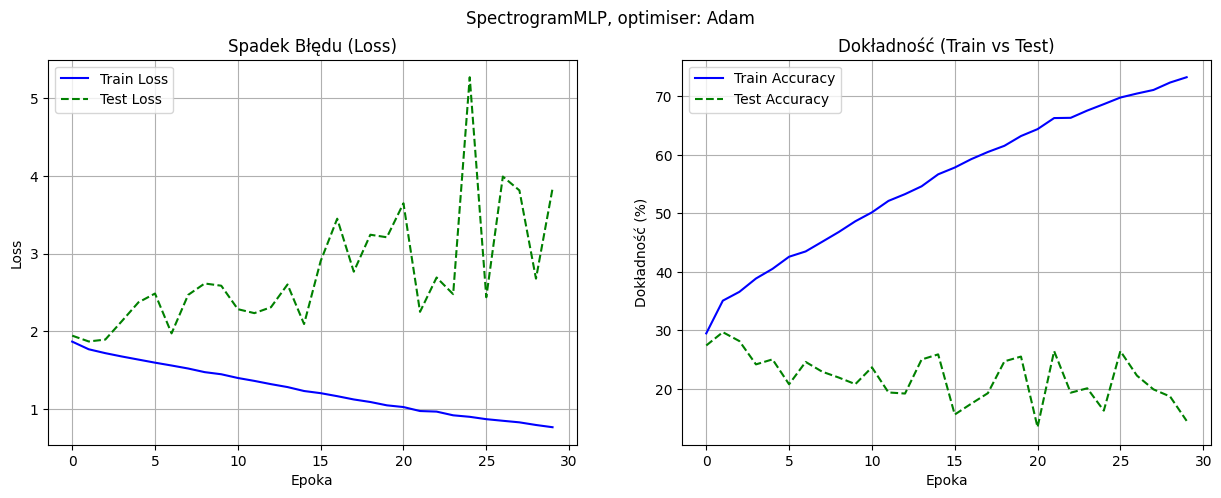


[KROK 4] Szczegółowy raport końcowy:
               precision    recall  f1-score   support

   Electronic       0.33      0.10      0.16       600
 Experimental       0.10      0.06      0.08       597
         Folk       0.55      0.01      0.02       600
      Hip-Hop       0.00      0.00      0.00       597
 Instrumental       0.14      0.98      0.24       600
International       1.00      0.01      0.01       600
          Pop       0.00      0.00      0.00       600
         Rock       0.50      0.00      0.00       600

     accuracy                           0.15      4794
    macro avg       0.33      0.15      0.06      4794
 weighted avg       0.33      0.15      0.06      4794



/Users/pawelmozaryn/MACHINE_LEARNING/Nonlinear_and_ml/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pawelmozaryn/MACHINE_LEARNING/Nonlinear_and_ml/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/pawelmozaryn/MACHINE_LEARNING/Nonlinear_and_ml/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

In [41]:
model_training_and_eval(SpectrogramMLP, SpectrogramDataset)

### 2.1 Standardowy CNN

Using device: mps
[KROK 2] Budowa sieci SpectrogramCNN...
[KROK 3] Start treningu (30 epok)...
Epoka 01 | Train Loss: 1.7752 Test Loss 1.7780|
 Train Acc: 33.66% | Test Acc: 32.14%
Epoka 02 | Train Loss: 1.6328 Test Loss 1.6745|
 Train Acc: 41.34% | Test Acc: 36.86%
Epoka 03 | Train Loss: 1.5735 Test Loss 1.5847|
 Train Acc: 44.01% | Test Acc: 42.47%
Epoka 04 | Train Loss: 1.5331 Test Loss 1.6398|
 Train Acc: 45.85% | Test Acc: 42.62%
Epoka 05 | Train Loss: 1.5087 Test Loss 1.6138|
 Train Acc: 46.43% | Test Acc: 40.63%
Epoka 06 | Train Loss: 1.4791 Test Loss 1.8758|
 Train Acc: 47.97% | Test Acc: 33.52%
Epoka 07 | Train Loss: 1.4639 Test Loss 1.9445|
 Train Acc: 48.45% | Test Acc: 35.27%
Epoka 08 | Train Loss: 1.4549 Test Loss 1.5263|
 Train Acc: 48.70% | Test Acc: 46.79%
Epoka 09 | Train Loss: 1.4341 Test Loss 1.9839|
 Train Acc: 50.01% | Test Acc: 35.65%
Epoka 10 | Train Loss: 1.4207 Test Loss 1.6005|
 Train Acc: 50.35% | Test Acc: 45.62%
Epoka 11 | Train Loss: 1.4059 Test Loss 1.570

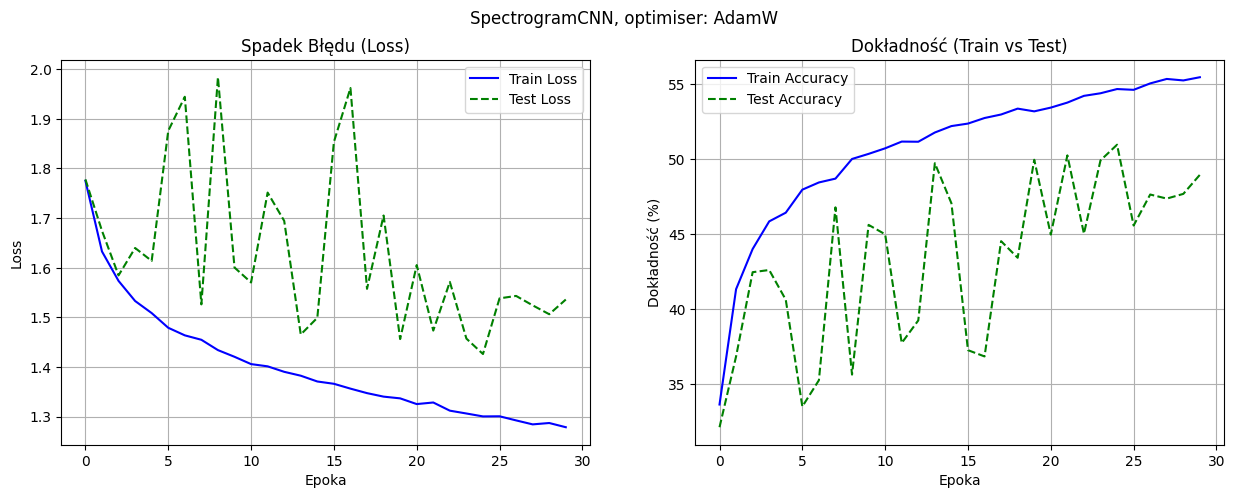


[KROK 4] Szczegółowy raport końcowy:
               precision    recall  f1-score   support

   Electronic       0.44      0.73      0.55       600
 Experimental       0.58      0.18      0.27       597
         Folk       0.60      0.56      0.58       600
      Hip-Hop       0.80      0.42      0.55       597
 Instrumental       0.52      0.53      0.53       600
International       0.57      0.61      0.59       600
          Pop       0.27      0.16      0.20       600
         Rock       0.39      0.73      0.51       600

     accuracy                           0.49      4794
    macro avg       0.52      0.49      0.47      4794
 weighted avg       0.52      0.49      0.47      4794



In [42]:
model_training_and_eval(SpectrogramCNN, SpectrogramCnnDataset, optim_algo=optim.AdamW)

### 2.2 CRNN

Using device: mps
[KROK 2] Budowa sieci CRNNSpectrogram...
[KROK 3] Start treningu (30 epok)...
Epoka 01 | Train Loss: 1.6138 Test Loss 1.6562|
 Train Acc: 41.85% | Test Acc: 40.13%
Epoka 02 | Train Loss: 1.4197 Test Loss 1.4962|
 Train Acc: 50.27% | Test Acc: 47.06%
Epoka 03 | Train Loss: 1.3444 Test Loss 1.6679|
 Train Acc: 53.15% | Test Acc: 43.95%
Epoka 04 | Train Loss: 1.2932 Test Loss 1.4667|
 Train Acc: 55.19% | Test Acc: 48.12%
Epoka 05 | Train Loss: 1.2403 Test Loss 1.4345|
 Train Acc: 56.91% | Test Acc: 49.83%
Epoka 06 | Train Loss: 1.2064 Test Loss 1.5047|
 Train Acc: 58.04% | Test Acc: 47.91%
Epoka 07 | Train Loss: 1.1588 Test Loss 1.5598|
 Train Acc: 60.07% | Test Acc: 45.95%
Epoka 08 | Train Loss: 1.1058 Test Loss 1.4311|
 Train Acc: 61.31% | Test Acc: 52.57%
Epoka 09 | Train Loss: 1.0472 Test Loss 1.4909|
 Train Acc: 63.49% | Test Acc: 50.50%
Epoka 10 | Train Loss: 0.9906 Test Loss 1.4211|
 Train Acc: 66.22% | Test Acc: 51.34%
Epoka 11 | Train Loss: 0.9271 Test Loss 1.74

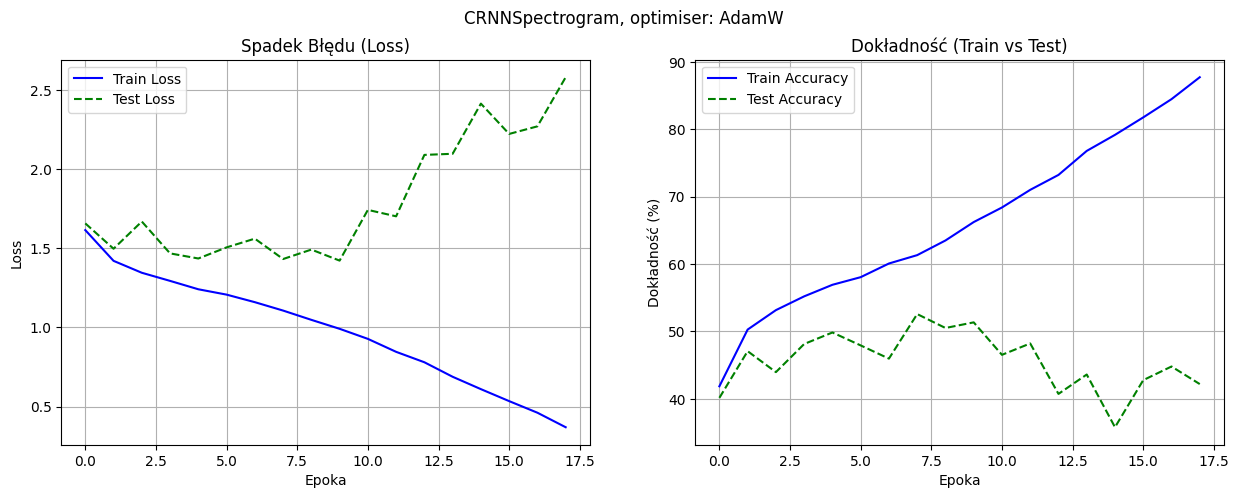


[KROK 4] Szczegółowy raport końcowy:
               precision    recall  f1-score   support

   Electronic       0.72      0.29      0.42       600
 Experimental       0.37      0.30      0.33       597
         Folk       0.76      0.28      0.41       600
      Hip-Hop       0.57      0.66      0.61       597
 Instrumental       0.49      0.56      0.53       600
International       0.57      0.54      0.56       600
          Pop       0.21      0.40      0.28       600
         Rock       0.50      0.63      0.55       600

     accuracy                           0.46      4794
    macro avg       0.52      0.46      0.46      4794
 weighted avg       0.52      0.46      0.46      4794



In [43]:
model_training_and_eval(CRNNSpectrogram, SpectrogramCnnDataset, optim.AdamW)

### 2.3 CNN z połączeniami rezydualnymi inspirowany siecią $ResNet18$

Using device: mps
[KROK 2] Budowa sieci ResNetSpectrogram...
[KROK 3] Start treningu (30 epok)...
Epoka 01 | Train Loss: 1.8388 Test Loss 1.6856|
 Train Acc: 30.40% | Test Acc: 37.78%
Epoka 02 | Train Loss: 1.6852 Test Loss 1.6143|
 Train Acc: 38.16% | Test Acc: 42.32%
Epoka 03 | Train Loss: 1.5905 Test Loss 1.5406|
 Train Acc: 42.86% | Test Acc: 44.33%
Epoka 04 | Train Loss: 1.5273 Test Loss 1.5044|
 Train Acc: 45.47% | Test Acc: 47.00%
Epoka 05 | Train Loss: 1.4838 Test Loss 1.4572|
 Train Acc: 47.61% | Test Acc: 48.23%
Epoka 06 | Train Loss: 1.4423 Test Loss 1.4415|
 Train Acc: 49.54% | Test Acc: 49.46%
Epoka 07 | Train Loss: 1.4011 Test Loss 1.4830|
 Train Acc: 50.96% | Test Acc: 47.33%
Epoka 08 | Train Loss: 1.3752 Test Loss 1.3926|
 Train Acc: 51.95% | Test Acc: 50.96%
Epoka 09 | Train Loss: 1.3538 Test Loss 1.3727|
 Train Acc: 52.84% | Test Acc: 52.21%
Epoka 10 | Train Loss: 1.3229 Test Loss 1.3875|
 Train Acc: 53.74% | Test Acc: 51.34%
Epoka 11 | Train Loss: 1.2940 Test Loss 1.

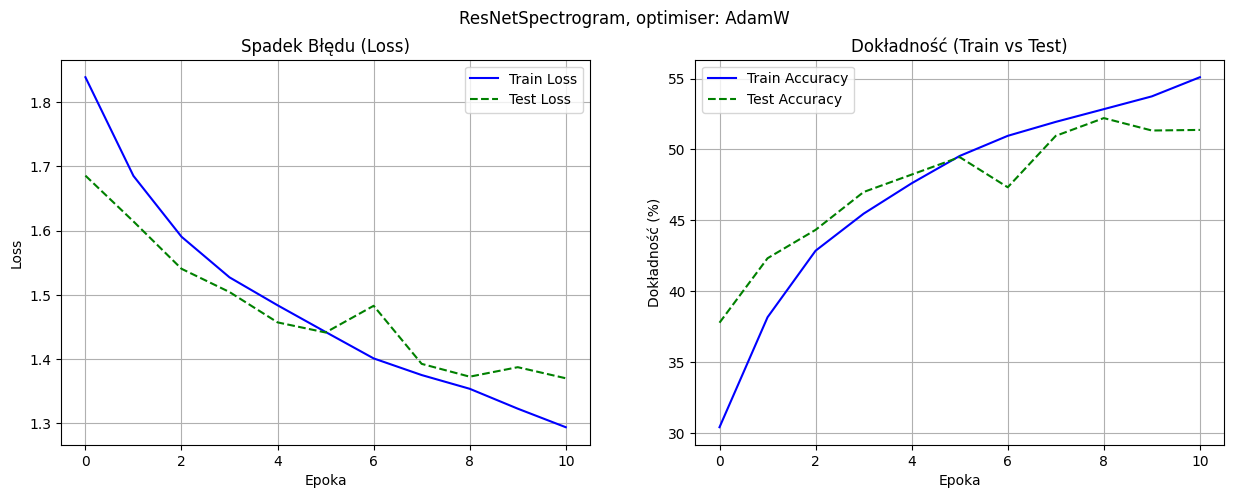


[KROK 4] Szczegółowy raport końcowy:
               precision    recall  f1-score   support

   Electronic       0.57      0.55      0.56       600
 Experimental       0.48      0.41      0.44       597
         Folk       0.52      0.59      0.55       600
      Hip-Hop       0.60      0.73      0.66       597
 Instrumental       0.51      0.63      0.56       600
International       0.57      0.55      0.56       600
          Pop       0.26      0.19      0.22       600
         Rock       0.59      0.55      0.57       600

     accuracy                           0.52      4794
    macro avg       0.51      0.52      0.51      4794
 weighted avg       0.51      0.52      0.51      4794



In [44]:
model_training_and_eval(ResNetSpectrogram, SpectrogramCnnDataset, optim.AdamW)

### Wnioski 

CRNN był najstabilniejszy - oraz w 8 epoce osiągnął 53%. Potem nastąpił overfitting. Próbujemy obnizyć wariancję modelu